# MACE memory-leak diagnosis: mtknpt vs velocity-verlet

Results from Slurm job 328 (`diagnose_mace_leak_array.sh`), task 0 = `mtknpt` (matches production NPT settings) on `globus1`, task 1 = `velocity-verlet` (fixed-cell control) on `globus2`. Both ran the same MOF structure, same MACE model, for 2000 steps, with zero cascade DB/Parsl code involved - just ASE + MACE directly (`diagnose_mace_leak.py`).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Okabe-Ito colorblind-safe pair, used consistently for these two cases across every plot below.
COLOR_MTKNPT = '#0072B2'  # production-like (NPT, changing cell)
COLOR_VV = '#D55E00'      # control (fixed cell)

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#dddddd',
    'grid.linewidth': 0.6,
    'figure.dpi': 110,
})

# Before: original leaking runs (job 328)
mtknpt = pd.read_csv('diag_mtknpt.328_0.csv').drop_duplicates(subset='step', keep='last')
vv = pd.read_csv('diag_vv.328_1.csv').drop_duplicates(subset='step', keep='last')

# After: both fixes applied - PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True + periodic
# torch.cuda.empty_cache() (job 330)
mtknpt_fixed = pd.read_csv('diag_mtknpt_fixed.330_0.csv').drop_duplicates(subset='step', keep='last')
vv_fixed = pd.read_csv('diag_vv_fixed.330_1.csv').drop_duplicates(subset='step', keep='last')

# 2x2 ablation of the two fixes on the mtknpt case (job 332; the other two corners are
# just mtknpt / mtknpt_fixed above - no control run needed, vv never leaked either way)
mtknpt_expseg_only = pd.read_csv('diag_mtknpt_expseg_only.332_0.csv').drop_duplicates(subset='step', keep='last')
mtknpt_emptycache_only = pd.read_csv('diag_mtknpt_emptycache_only.332_1.csv').drop_duplicates(subset='step', keep='last')

for name, df in [('mtknpt (before)', mtknpt), ('vv (before)', vv),
                  ('mtknpt (after)', mtknpt_fixed), ('vv (after)', vv_fixed),
                  ('mtknpt (expandable_segments only)', mtknpt_expseg_only),
                  ('mtknpt (empty_cache only)', mtknpt_emptycache_only)]:
    print(f'{name}: {len(df)} samples, {df.wall_time_s.max():.0f}s wall time')

mtknpt (before): 101 samples, 312s wall time
vv (before): 101 samples, 221s wall time
mtknpt (after): 101 samples, 328s wall time
vv (after): 101 samples, 222s wall time
mtknpt (expandable_segments only): 101 samples, 312s wall time
mtknpt (empty_cache only): 101 samples, 317s wall time


## 1. GPU reserved memory, before vs after the fix

`gpu_reserved_mb` is PyTorch's CUDA caching-allocator footprint (`torch.cuda.memory_reserved()`) - memory the allocator has claimed from the driver, whether or not it's currently in use by a live tensor. "Before" = job 328 (original). "After" = job 330, same settings plus `PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True` and periodic `torch.cuda.empty_cache()`. Both panels share the same y-axis so the difference is directly comparable.

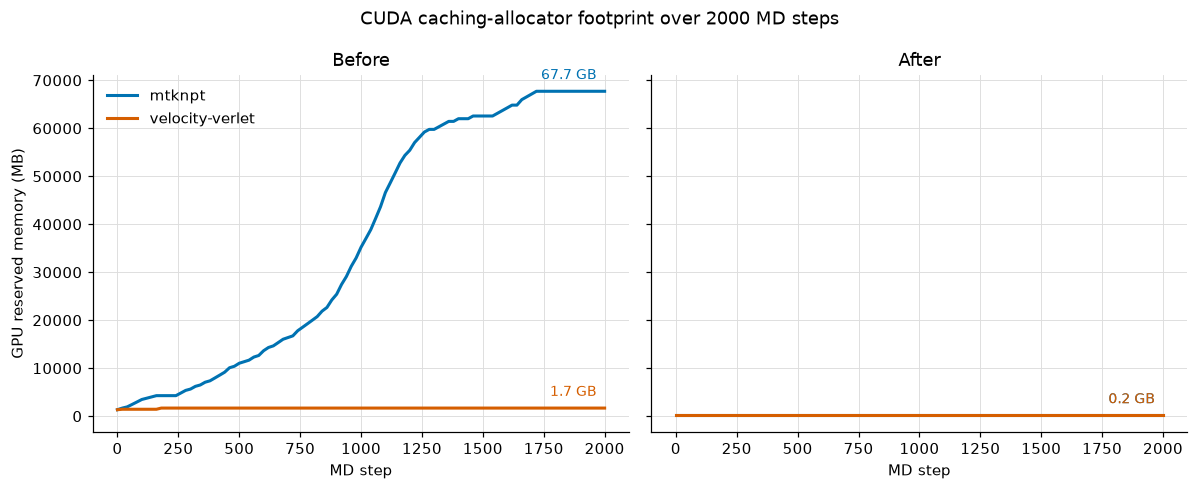

In [2]:
fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, mk, vv_df, title in [(ax_before, mtknpt, vv, 'Before'), (ax_after, mtknpt_fixed, vv_fixed, 'After')]:
    ax.plot(mk.step, mk.gpu_reserved_mb, color=COLOR_MTKNPT, linewidth=2, label='mtknpt')
    ax.plot(vv_df.step, vv_df.gpu_reserved_mb, color=COLOR_VV, linewidth=2, label='velocity-verlet')
    ax.set_xlabel('MD step')
    ax.set_title(title)
    ax.annotate(f'{mk.gpu_reserved_mb.iloc[-1]/1000:.1f} GB', (mk.step.iloc[-1], mk.gpu_reserved_mb.iloc[-1]),
                xytext=(-5, 8), textcoords='offset points', ha='right', color=COLOR_MTKNPT, fontsize=9)
    ax.annotate(f'{vv_df.gpu_reserved_mb.iloc[-1]/1000:.1f} GB', (vv_df.step.iloc[-1], vv_df.gpu_reserved_mb.iloc[-1]),
                xytext=(-5, 8), textcoords='offset points', ha='right', color=COLOR_VV, fontsize=9)

ax_before.set_ylabel('GPU reserved memory (MB)')
ax_before.legend(frameon=False)
fig.suptitle('CUDA caching-allocator footprint over 2000 MD steps')

plt.tight_layout()
plt.show()

## 2. Host available memory, before vs after the fix

`nvidia-smi` reports this GPU as an **NVIDIA GB10** (Grace-Blackwell unified memory) - `memory.total` comes back `N/A` because there's no separate discrete VRAM pool; GPU memory *is* system RAM on this hardware. So `host_available_mb` should fall in lockstep with `gpu_reserved_mb` for the leaking run - and if the fix works, it should stay flat like the control.

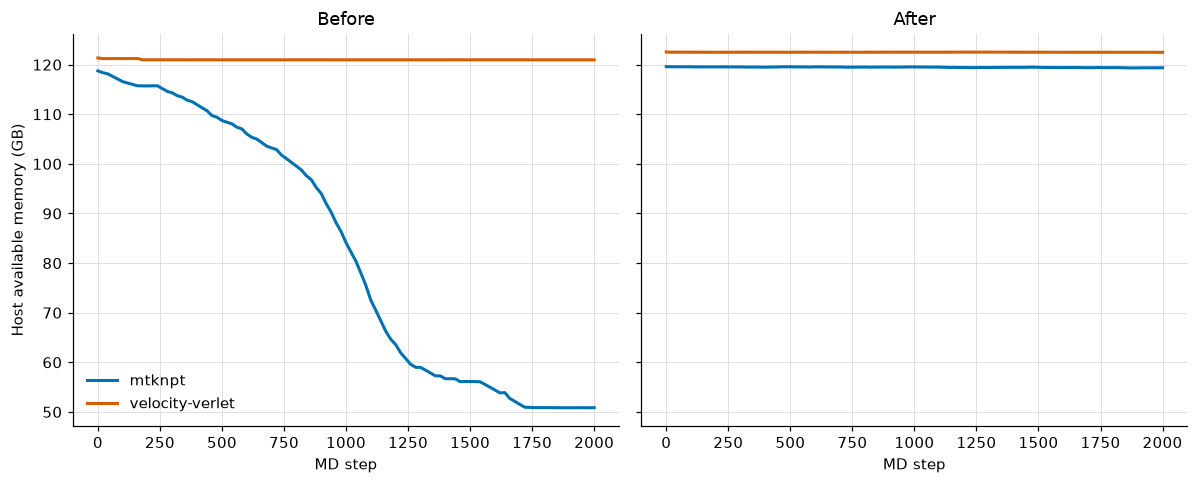

In [3]:
fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, mk, vv_df, title in [(ax_before, mtknpt, vv, 'Before'), (ax_after, mtknpt_fixed, vv_fixed, 'After')]:
    ax.plot(mk.step, mk.host_available_mb / 1000, color=COLOR_MTKNPT, linewidth=2, label='mtknpt')
    ax.plot(vv_df.step, vv_df.host_available_mb / 1000, color=COLOR_VV, linewidth=2, label='velocity-verlet')
    ax.set_xlabel('MD step')
    ax.set_title(title)
    drop_gb = (mk.host_available_mb.iloc[0] - mk.host_available_mb.iloc[-1]) / 1000
    # ax.annotate(f'-{drop_gb:.1f} GB', (mk.step.iloc[-1], mk.host_available_mb.iloc[-1] / 1000),
    #             xytext=(-5, -14), textcoords='offset points', ha='right', color=COLOR_MTKNPT, fontsize=9)

ax_before.set_ylabel('Host available memory (GB)')
ax_before.legend(frameon=False)
#fig.suptitle('System-wide available memory over 2000 MD steps')

plt.tight_layout()
plt.show()

## 3. Why the original run leaks: the cell is collapsing, so the neighbor list keeps changing shape

Same 424 atoms throughout - but under 1.0 GPa external pressure at 200 K, this MOF's cell volume drops fast, packing atoms closer together and continuously changing how many pairs fall within the cutoff radius (`n_edges`). `mace_mp()` wasn't given a fixed `pad_num_atoms`/`pad_num_edges`, so every distinct edge count is a new tensor shape for PyTorch's allocator - it can't reuse a differently-sized freed block, so (without the fix) it keeps asking the driver for more. This physical collapse is unaffected by the allocator fix, which is exactly the point: the shape churn still happens, but the allocator now handles it without leaking (see section 1).

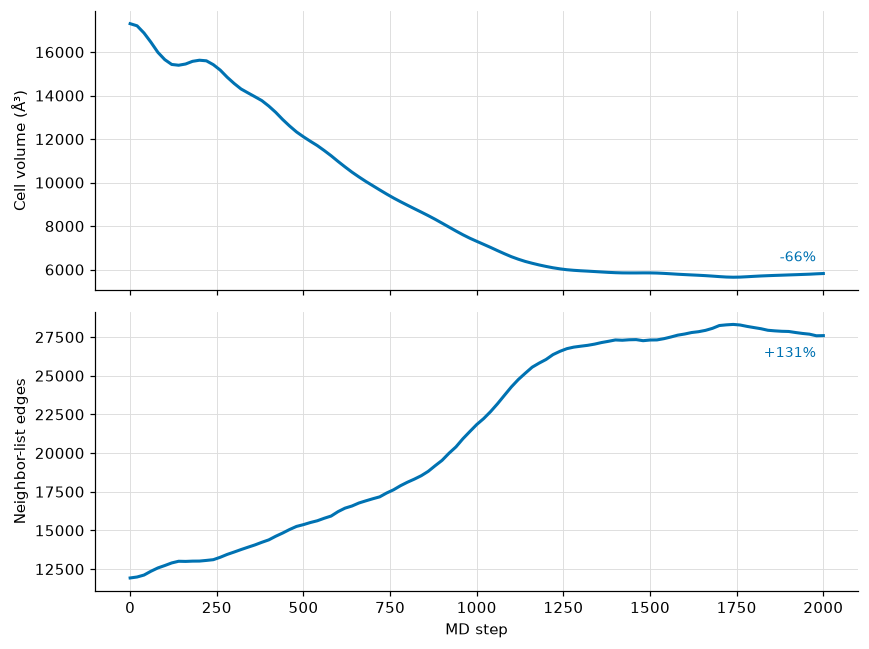

In [4]:
fig, (ax_vol, ax_edges) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax_vol.plot(mtknpt.step, mtknpt.volume_A3, color=COLOR_MTKNPT, linewidth=2)
ax_vol.set_ylabel('Cell volume (Å³)')
#ax_vol.set_title('')
vol_drop_pct = 100 * (1 - mtknpt.volume_A3.iloc[-1] / mtknpt.volume_A3.iloc[0])
ax_vol.annotate(f'-{vol_drop_pct:.0f}%', (mtknpt.step.iloc[-1], mtknpt.volume_A3.iloc[-1]),
                 xytext=(-5, 8), textcoords='offset points', ha='right', color=COLOR_MTKNPT, fontsize=9)

ax_edges.plot(mtknpt.step, mtknpt.n_edges, color=COLOR_MTKNPT, linewidth=2)
ax_edges.set_xlabel('MD step')
ax_edges.set_ylabel('Neighbor-list edges')
edge_growth_pct = 100 * (mtknpt.n_edges.iloc[-1] / mtknpt.n_edges.iloc[0] - 1)
ax_edges.annotate(f'+{edge_growth_pct:.0f}%', (mtknpt.step.iloc[-1], mtknpt.n_edges.iloc[-1]),
                   xytext=(-5, -14), textcoords='offset points', ha='right', color=COLOR_MTKNPT, fontsize=9)

plt.tight_layout()
plt.show()

## 4. Ablation: which fix actually matters?

Two candidate fixes were bundled together in section 1: `PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True` and periodic `torch.cuda.empty_cache()`. The 2x2 below (job 332 fills the two new corners; "neither" and "both" reuse the mtknpt runs from jobs 328/330) isolates which one is doing the work, using each run's final `gpu_reserved_mb` after 2000 steps.

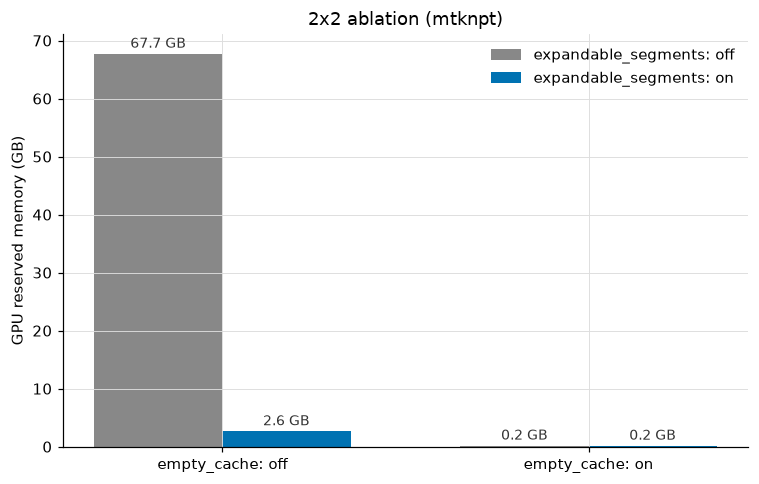

In [5]:
import numpy as np

COLOR_EXPSEG_OFF = '#888888'  # expandable_segments off
COLOR_EXPSEG_ON = '#0072B2'   # expandable_segments on

final_gb = {
    ('off', 'off'): mtknpt.gpu_reserved_mb.iloc[-1] / 1000,
    ('on', 'off'): mtknpt_expseg_only.gpu_reserved_mb.iloc[-1] / 1000,
    ('off', 'on'): mtknpt_emptycache_only.gpu_reserved_mb.iloc[-1] / 1000,
    ('on', 'on'): mtknpt_fixed.gpu_reserved_mb.iloc[-1] / 1000,
}

groups = ['empty_cache: off', 'empty_cache: on']
x = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
bars_off = ax.bar(x - width / 2, [final_gb[('off', 'off')], final_gb[('off', 'on')]],
                   width, color=COLOR_EXPSEG_OFF, label='expandable_segments: off')
bars_on = ax.bar(x + width / 2, [final_gb[('on', 'off')], final_gb[('on', 'on')]],
                  width, color=COLOR_EXPSEG_ON, label='expandable_segments: on')

for bars in (bars_off, bars_on):
    for b in bars:
        ax.annotate(f'{b.get_height():.1f} GB', (b.get_x() + b.get_width() / 2, b.get_height()),
                    xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel('GPU reserved memory (GB)')
ax.set_title('2x2 ablation (mtknpt)')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## Conclusion

- **Before** (job 328): the production-like `mtknpt` run loses ~68 GB of host-available memory in ~5 minutes; the `velocity-verlet` control barely moves.
- **After** (job 330, `PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True` + periodic `torch.cuda.empty_cache()`): compare the "After" panels above directly against "Before" - `mtknpt` should now track the control instead of climbing unbounded.
- The trigger is physical, not code: this NPT run compresses the MOF cell by roughly two-thirds in 2000 fs, continuously changing the neighbor-list edge count fed to MACE. The fix doesn't stop that physical churn (section 3) - it stops PyTorch's CUDA allocator from leaking memory in response to it.
- On this hardware (NVIDIA GB10, unified CPU+GPU memory), "GPU reserved" and "host available" are the same physical pool, so fixing the allocator growth directly fixes the host-memory starvation that caused the original production run to swap and go unresponsive.

If the "after" panels still show growth (even if smaller), the allocator-level fixes are only a mitigation, not a full fix - next step would be pinning the batch shape via `mace_mp(..., pad_num_atoms=N, pad_num_edges=M)` so the tensor shape stops changing altogether. If they're flat, roll both fixes into `run_reference_dynamics.py`/`.sh` for the real production run.